<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/FUNt_Space_Weather_hHRT_Operator_Research_Edition_v1_0_Core_Engine_Transition_Ledger_v0_7_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FUNt Space Weather Transition Ledger v0.7.2

**Purpose:** monitor space-weather performance while keeping the model causal, teachable, auditable, and bounded by persistence plus Earth-geometry coupling.

This version adds two missing boundary conditions:

> **Persistence survival:** a transition signal must survive **x consecutive windows** before h3pi is accepted as confirmed.  
> **Earth-geometry gate:** transition pressure must also have a favorable enough Earth/magnetosphere geometry at the event time to couple into a Kp-scale response.

The notebook keeps **raw transition pressure** visible, but separates it from the **final Kp estimate**. A sharp pressure needle can be real as a physical impulse, but it is not allowed to become a storm-regime estimate unless it survives persistence and geometry gates.

## What this notebook does

1. Fetches public SWPC/NOAA space-weather JSON feeds when internet is available.
2. Builds a causal transition ledger from current and prior measurements only.
3. Computes approximate Earth-geometry coupling from timestamp-only geometry proxies.
4. Keeps observed Kp as **validation only**.
5. Plots Estimate vs Actual as the attention hook.
6. Adds raw-pressure audit, persistence survival audit, geometry audit, and event logs so the chart explains itself.

Core teaching rule:

> Disturbance alone is not transition.  
> Transport alone is not transition.  
> A spike alone is not transition.  
> Only persistent, threshold-crossing strain with admissible geometry becomes regime change.


## Notebook philosophy

Every run should answer five reader questions:

1. **What happened?** Estimate vs actual Kp.
2. **Why did it happen?** Perturbation, transport, persistence, relaxation, h3pi gate.
3. **How did the model decide?** Ledger columns and verdict box.
4. **What should be watched next?** Aftershock / relaxation state only.
5. **What is Nature teaching?** Persistent systems correct most disturbances before transition.



In [1]:
# ============================================================
# FUNt Space Weather Transition Ledger v0.7.2
# ============================================================

import json
import math
import os
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional, Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

VERSION = "v0.7.2-geometry-gate-persistence-survival"
UTC_NOW = datetime.now(timezone.utc)

print("FUNt Space Weather Transition Ledger", VERSION)
print("Run UTC:", UTC_NOW.isoformat())


FUNt Space Weather Transition Ledger v0.7.2-geometry-gate-persistence-survival
Run UTC: 2026-06-17T17:11:08.320135+00:00


## Boundary conditions

These are not decoration. They prevent the model from becoming a curve-fitting toy.

### 1. Causality boundary
Use only data available at prediction time. Observed Kp is used for validation, not to construct the estimate.

### 2. Transition boundary
A regime transition is logged only when the **confirmed h3pi gate** is true.

```text
T > |Psi|
E >= h3pi
tau >= tau_HRT
signal survives x consecutive windows
G >= G_min
```

### 3. Persistence survival boundary
One spike is not enough. A candidate transition must survive `survival_windows_x` consecutive windows before it is confirmed.

### 4. Earth-geometry boundary
The same solar input does not couple to Earth identically at every time. The notebook adds a timestamp-only geometry factor `G_geometry` and requires `G >= G_min` before storm-regime prediction is allowed.

### 5. No-transition cap
If the confirmed h3pi gate is false, the final Kp estimate is capped.

### 6. Raw-pressure boundary
Raw transition pressure is retained for diagnosis. It may spike. The final estimate may not follow it unless boundary gates confirm transition.

### 7. Relaxation boundary
If transport is not reinforced, accumulated persistence must decay.

### 8. Humility boundary
If Nature disagrees with the model, the model is revised, not Nature.


In [2]:
# --------------------- CONFIG ---------------------

CONFIG = {
    "version": VERSION,

    # FUNt constants / thresholds
    "h3pi": 3.0 * math.pi,           # transition-energy gate
    "tau_HRT": 3,                    # consecutive transport windows required
    "survival_windows_x": 3,         # signal must survive x consecutive full-candidate windows
    "gate_confirm_windows": 3,       # kept for backward compatibility; mirrors survival_windows_x
    "psi_floor": 1.4656,             # user anchor; used as persistence reference

    # Earth-geometry gate. This is a first-pass proxy, not a final geophysical model.
    "geometry_gate_min": 0.62,
    "geometry_floor": 0.40,          # never let geometry erase physical pressure completely
    "geometry_utc_weight": 0.45,
    "geometry_season_weight": 0.35,
    "geometry_dipole_weight": 0.20,

    # Model response behavior
    "kp_base": 1.0,
    "kp_cap_no_transition": 3.0,
    "quiet_gain": 0.35,
    "storm_gain": 1.20,
    "relaxation_rate": 0.18,
    "persistence_gain": 0.42,

    # Classification thresholds
    "perturbation_threshold": 0.20,
    "transport_threshold": 0.30,
    "high_pressure_threshold": 0.70,
    "aftershock_watch_threshold": 0.55,
    "raw_pressure_audit_threshold": 3.0,
    "needle_multiplier": 2.0,        # flags sharp one-sample raw pressure jumps

    # Data handling
    "local_data_dir": "funt_space_weather_data",
    "prediction_log_csv": "funt_space_weather_predictions_v072.csv",

    # NOAA/SWPC JSON endpoints. These may change; see NOAA SWPC service notices.
    "endpoints": {
        "kp_observed_3h": "https://services.swpc.noaa.gov/products/noaa-planetary-k-index.json",
        "kp_estimated_1m": "https://services.swpc.noaa.gov/products/noaa-estimated-planetary-k-index-1-minute.json",
        "goes_magnetometer_1m": "https://services.swpc.noaa.gov/json/goes/primary/magnetometers-1-day.json",
        "goes_electron_flux_5m": "https://services.swpc.noaa.gov/json/goes/primary/integral-electrons-1-day.json",
        "solar_wind_mag_1h": "https://services.swpc.noaa.gov/products/solar-wind/mag-1-hour.json",
        "solar_wind_plasma_1h": "https://services.swpc.noaa.gov/products/solar-wind/plasma-1-hour.json",
    }
}

Path(CONFIG["local_data_dir"]).mkdir(exist_ok=True)
print(json.dumps({k:v for k,v in CONFIG.items() if k != "endpoints"}, indent=2))


{
  "version": "v0.7.2-geometry-gate-persistence-survival",
  "h3pi": 9.42477796076938,
  "tau_HRT": 3,
  "survival_windows_x": 3,
  "gate_confirm_windows": 3,
  "psi_floor": 1.4656,
  "geometry_gate_min": 0.62,
  "geometry_floor": 0.4,
  "geometry_utc_weight": 0.45,
  "geometry_season_weight": 0.35,
  "geometry_dipole_weight": 0.2,
  "kp_base": 1.0,
  "kp_cap_no_transition": 3.0,
  "quiet_gain": 0.35,
  "storm_gain": 1.2,
  "relaxation_rate": 0.18,
  "persistence_gain": 0.42,
  "perturbation_threshold": 0.2,
  "transport_threshold": 0.3,
  "high_pressure_threshold": 0.7,
  "aftershock_watch_threshold": 0.55,
  "raw_pressure_audit_threshold": 3.0,
  "needle_multiplier": 2.0,
  "local_data_dir": "funt_space_weather_data",
  "prediction_log_csv": "funt_space_weather_predictions_v072.csv"
}


## Data loading

The notebook tries live NOAA/SWPC feeds first. If a feed fails, it prints the failure and continues with whatever data is available. This lets the notebook run in restricted environments and still preserve the audit structure.



In [3]:
import urllib.request
import urllib.error


def fetch_json(url: str, timeout: int = 6) -> Any:
    """Fetch JSON from URL. Returns Python object or raises exception."""
    req = urllib.request.Request(url, headers={"User-Agent": "FUNt-Transition-Ledger/0.7"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return json.loads(r.read().decode("utf-8"))


def safe_fetch(name: str, url: str) -> Optional[Any]:
    try:
        data = fetch_json(url)
        out = Path(CONFIG["local_data_dir"]) / f"{name}_{UTC_NOW.strftime('%Y%m%dT%H%M%SZ')}.json"
        out.write_text(json.dumps(data)[:20_000_000])
        print(f"OK: {name} rows/items saved -> {out}")
        return data
    except Exception as e:
        print(f"FAILED: {name}: {type(e).__name__}: {e}")
        return None

raw = {name: safe_fetch(name, url) for name, url in CONFIG["endpoints"].items()}


OK: kp_observed_3h rows/items saved -> funt_space_weather_data/kp_observed_3h_20260617T171108Z.json
FAILED: kp_estimated_1m: HTTPError: HTTP Error 404: Not Found
OK: goes_magnetometer_1m rows/items saved -> funt_space_weather_data/goes_magnetometer_1m_20260617T171108Z.json
OK: goes_electron_flux_5m rows/items saved -> funt_space_weather_data/goes_electron_flux_5m_20260617T171108Z.json
FAILED: solar_wind_mag_1h: HTTPError: HTTP Error 404: Not Found
FAILED: solar_wind_plasma_1h: HTTPError: HTTP Error 404: Not Found


In [4]:
# --------------------- PARSERS ---------------------


def parse_time_series_json(data, time_cols=("time_tag", "time", "timestamp", "DateTime")) -> pd.DataFrame:
    """Parse common SWPC JSON structures into a DataFrame with UTC datetime index."""
    if data is None:
        return pd.DataFrame()

    # Some SWPC product feeds are list-of-lists with header row.
    if isinstance(data, list) and len(data) > 0 and isinstance(data[0], list):
        header = data[0]
        rows = data[1:]
        df = pd.DataFrame(rows, columns=header)
    elif isinstance(data, list) and (len(data) == 0 or isinstance(data[0], dict)):
        df = pd.DataFrame(data)
    elif isinstance(data, dict):
        # Try common payload keys.
        for key in ("data", "observations", "products"):
            if key in data and isinstance(data[key], list):
                return parse_time_series_json(data[key], time_cols=time_cols)
        df = pd.DataFrame([data])
    else:
        return pd.DataFrame()

    if df.empty:
        return df

    time_col = None
    for c in time_cols:
        if c in df.columns:
            time_col = c
            break
    if time_col is None:
        # Fall back to first column if it looks time-like.
        time_col = df.columns[0]

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df = df.dropna(subset=[time_col]).sort_values(time_col).set_index(time_col)

    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="ignore")
    return df


def numeric_columns(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

frames = {name: parse_time_series_json(data) for name, data in raw.items()}
for name, df in frames.items():
    print("\n", name, df.shape)
    if not df.empty:
        display(df.tail(3))



 kp_observed_3h (61, 3)


/tmp/ipykernel_2465/976565981.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_2465/976565981.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_2465/976565981.py:41: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


,Kp,a_running,station_count
time_tag,,,
2026-06-17 06:00:00+00:00,2.00,7,8
2026-06-17 09:00:00+00:00,2.33,9,8
2026-06-17 12:00:00+00:00,2.33,9,8



 kp_estimated_1m (0, 0)

 goes_magnetometer_1m (1439, 6)


,satellite,He,Hp,Hn,total,arcjet_flag
time_tag,,,,,,
2026-06-17 17:07:00+00:00,18,18.275637,99.060905,21.467684,102.994843,False
2026-06-17 17:08:00+00:00,18,18.024162,99.183296,21.520588,103.079330,False
2026-06-17 17:09:00+00:00,18,17.872231,99.286171,21.410286,103.128937,False



 goes_electron_flux_5m (286, 3)


,satellite,flux,energy
time_tag,,,
2026-06-17 16:50:00+00:00,19,427.149353,>=2 MeV
2026-06-17 16:55:00+00:00,19,596.325806,>=2 MeV
2026-06-17 17:00:00+00:00,19,465.117004,>=2 MeV



 solar_wind_mag_1h (0, 0)

 solar_wind_plasma_1h (0, 0)


## Feature construction

The model builds simple normalized signals from available feeds:

- **Magnetic perturbation:** recent change / dispersion in GOES magnetic field.
- **Electron disturbance:** sudden log-flux change or depletion.
- **Solar wind pressure proxy:** velocity and density when available.
- **Bz stress:** southward IMF Bz contribution when available.

The exact feature set can be expanded, but the ledger logic should remain stable.



In [5]:
# --------------------- FEATURE HELPERS ---------------------


def robust_z(series: pd.Series, window: int = 180, min_periods: int = 20) -> pd.Series:
    """Rolling robust z-score using median and MAD. Causal because it only uses prior/current window."""
    s = pd.to_numeric(series, errors="coerce")
    med = s.rolling(window, min_periods=min_periods).median()
    mad = (s - med).abs().rolling(window, min_periods=min_periods).median()
    return ((s - med) / (1.4826 * mad.replace(0, np.nan))).replace([np.inf, -np.inf], np.nan).fillna(0)


def unit_clip(x, scale=4.0):
    return np.clip(np.abs(x) / scale, 0, 1)


def build_feature_frame(frames: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    # Establish a common time axis from the densest available feed.
    candidates = [(name, df) for name, df in frames.items() if not df.empty]
    if not candidates:
        return pd.DataFrame()
    base_name, base = max(candidates, key=lambda x: len(x[1]))
    idx = base.index.sort_values().unique()
    out = pd.DataFrame(index=idx)

    # GOES magnetometer feature
    mag = frames.get("goes_magnetometer_1m", pd.DataFrame())
    if not mag.empty:
        cols = numeric_columns(mag)
        # Prefer Hp or total field columns if present; otherwise first numeric column.
        pref = [c for c in cols if c.lower() in ("hp", "he", "hn", "total", "bt") or "hp" in c.lower()]
        col = pref[0] if pref else (cols[0] if cols else None)
        if col:
            m = pd.to_numeric(mag[col], errors="coerce")
            mag_disturb = robust_z(m.diff().abs().rolling(5, min_periods=1).mean(), window=240)
            out["magnetic_perturbation"] = unit_clip(mag_disturb).reindex(out.index, method="nearest", tolerance=pd.Timedelta("3min"))

    # Electron flux feature
    ele = frames.get("goes_electron_flux_5m", pd.DataFrame())
    if not ele.empty:
        cols = numeric_columns(ele)
        pref = [c for c in cols if "flux" in c.lower()]
        col = pref[0] if pref else (cols[0] if cols else None)
        if col:
            e = pd.to_numeric(ele[col], errors="coerce")
            loge = np.log10(e.clip(lower=1e-12))
            # Both sudden drop and sudden rise can signal reconfiguration; use absolute log change.
            ele_disturb = robust_z(loge.diff().abs().rolling(3, min_periods=1).mean(), window=120)
            out["electron_disturbance"] = unit_clip(ele_disturb).reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))

    # Solar wind magnetic Bz feature
    swmag = frames.get("solar_wind_mag_1h", pd.DataFrame())
    if not swmag.empty:
        cols = numeric_columns(swmag)
        bz_col = next((c for c in cols if c.lower() == "bz_gsm" or "bz" in c.lower()), None)
        if bz_col:
            bz = pd.to_numeric(swmag[bz_col], errors="coerce")
            southward = (-bz).clip(lower=0)
            bz_stress = (southward / 10.0).clip(0, 1)
            out["bz_southward_stress"] = bz_stress.reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))

    # Solar wind plasma feature
    plasma = frames.get("solar_wind_plasma_1h", pd.DataFrame())
    if not plasma.empty:
        cols = numeric_columns(plasma)
        speed_col = next((c for c in cols if "speed" in c.lower()), None)
        dens_col = next((c for c in cols if "density" in c.lower() or c.lower() == "density"), None)
        if speed_col:
            v = pd.to_numeric(plasma[speed_col], errors="coerce")
            v_stress = ((v - 350.0) / 350.0).clip(lower=0, upper=1)
            out["solar_wind_speed_stress"] = v_stress.reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))
        if dens_col:
            n = pd.to_numeric(plasma[dens_col], errors="coerce")
            n_stress = (np.log1p(n) / np.log1p(50)).clip(0, 1)
            out["solar_wind_density_stress"] = n_stress.reindex(out.index, method="nearest", tolerance=pd.Timedelta("8min"))

    # Observed Kp for validation only.
    kp = frames.get("kp_observed_3h", pd.DataFrame())
    if not kp.empty:
        cols = numeric_columns(kp)
        kp_col = next((c for c in cols if "kp" in c.lower() or "k" == c.lower()), None)
        if kp_col is None and cols:
            kp_col = cols[-1]
        if kp_col:
            out["observed_kp_validation_only"] = pd.to_numeric(kp[kp_col], errors="coerce").reindex(out.index, method="ffill")

    out = out.sort_index()
    feature_cols = [c for c in out.columns if c != "observed_kp_validation_only"]
    out[feature_cols] = out[feature_cols].fillna(0)
    return out

features = build_feature_frame(frames)
print(features.shape)
display(features.tail(10))


(1439, 3)


,magnetic_perturbation,electron_disturbance,observed_kp_validation_only
time_tag,,,
2026-06-17 17:00:00+00:00,0.003869,0.252985,2.33
2026-06-17 17:01:00+00:00,0.029157,0.252985,2.33
2026-06-17 17:02:00+00:00,0.006903,0.252985,2.33
2026-06-17 17:03:00+00:00,0.091691,0.252985,2.33
2026-06-17 17:04:00+00:00,0.158617,0.252985,2.33
2026-06-17 17:05:00+00:00,0.177510,0.252985,2.33
2026-06-17 17:06:00+00:00,0.171038,0.252985,2.33
2026-06-17 17:07:00+00:00,0.202207,0.252985,2.33
2026-06-17 17:08:00+00:00,0.147744,0.252985,2.33


In [6]:
# If live data is unavailable, create a small synthetic example so readers can inspect the model mechanics.
# Synthetic mode is clearly labeled and should never be used as validation.

if features.empty or len(features) < 10:
    print("Live data unavailable or insufficient. Using synthetic demonstration data only.")
    idx = pd.date_range(end=UTC_NOW, periods=120, freq="5min")
    x = np.linspace(0, 1, len(idx))
    features = pd.DataFrame(index=idx)
    features["magnetic_perturbation"] = 0.08 + 0.65*np.exp(-((x-0.55)/0.10)**2)
    features["electron_disturbance"] = 0.05 + 0.45*np.exp(-((x-0.50)/0.08)**2)
    features["bz_southward_stress"] = 0.15*np.exp(-((x-0.52)/0.11)**2)
    features["solar_wind_speed_stress"] = 0.10*np.exp(-((x-0.60)/0.20)**2)
    features["observed_kp_validation_only"] = 1.7 + 0.5*np.exp(-((x-0.62)/0.14)**2)
    features.attrs["synthetic"] = True
else:
    features.attrs["synthetic"] = False

print("Synthetic demonstration mode:", features.attrs.get("synthetic", False))


Synthetic demonstration mode: False


## FUNt transition ledger

The ledger distinguishes these quantities:

```text
Potential difference / perturbation: the error or imbalance entering the system.
Transport T: how strongly the system is being driven to reorganize.
Persistence Psi: accumulated strain after relaxation leakage.
Survival x: whether the signal persists long enough to matter.
G geometry: whether Earth's time/tilt geometry admits coupling.
E transition pressure: causal pressure toward the h3pi gate.
Raw transition pressure: what the model wanted to say before boundary discipline.
Final Kp estimate: what the model is allowed to say after boundary discipline.
```

Important v0.7.2 change:

> A spike may be physically interesting, but it is only a **candidate** until it survives x windows and passes the geometry gate.


In [7]:
# --------------------- FUNt LEDGER v0.7.2 ---------------------


def consecutive_true_count(s: pd.Series) -> pd.Series:
    """Causal consecutive TRUE counter."""
    b = s.fillna(False).astype(bool)
    return b.astype(int).groupby((~b).cumsum()).cumsum()


def earth_geometry_proxy(index: pd.DatetimeIndex, cfg: Dict[str, Any]) -> pd.DataFrame:
    """
    First-pass causal Earth-geometry coupling proxy.

    Uses timestamp-only terms so it cannot leak future Kp:
    - UTC/local-time phase proxy: Earth rotates under the solar wind/magnetosphere.
    - Seasonal tilt proxy: axial tilt changes magnetospheric coupling geometry through the year.
    - Dipole wobble proxy: simple diurnal harmonic placeholder for geomagnetic orientation.

    This is intentionally transparent and replaceable. Later versions can replace this with
    real dipole tilt, subsolar point, GSM coordinates, GOES local time, and solar-wind lag.
    """
    idx = pd.DatetimeIndex(index).tz_convert("UTC") if pd.DatetimeIndex(index).tz is not None else pd.DatetimeIndex(index).tz_localize("UTC")
    hour = idx.hour + idx.minute / 60.0 + idx.second / 3600.0
    doy = idx.dayofyear + hour / 24.0

    # UTC phase: broad 24-hour coupling harmonic, normalized to [0, 1].
    # The phase offset is deliberately configurable in future versions; 09 UTC is a neutral first-pass anchor.
    utc_phase = 0.5 + 0.5 * np.cos(2.0 * np.pi * (hour - 9.0) / 24.0)

    # Seasonal tilt: absolute seasonal exposure proxy, normalized [0, 1].
    season_phase = 0.5 + 0.5 * np.sin(2.0 * np.pi * (doy - 80.0) / 365.25)

    # Dipole wobble placeholder: 12-hour harmonic, normalized [0, 1].
    dipole_phase = 0.5 + 0.5 * np.cos(2.0 * np.pi * (hour - 3.0) / 12.0)

    G_raw = (
        cfg["geometry_utc_weight"] * utc_phase
        + cfg["geometry_season_weight"] * season_phase
        + cfg["geometry_dipole_weight"] * dipole_phase
    )
    G = cfg["geometry_floor"] + (1.0 - cfg["geometry_floor"]) * G_raw

    return pd.DataFrame({
        "geometry_utc_phase": utc_phase,
        "geometry_season_phase": season_phase,
        "geometry_dipole_phase": dipole_phase,
        "G_geometry": np.clip(G, 0, 1),
    }, index=index)


def compute_funt_ledger(features: pd.DataFrame, cfg: Dict[str, Any]) -> pd.DataFrame:
    df = features.copy()
    feature_cols = [c for c in df.columns if c != "observed_kp_validation_only"]

    # Weighted perturbation index. Keep transparent and editable.
    weights = {
        "magnetic_perturbation": 0.35,
        "electron_disturbance": 0.25,
        "bz_southward_stress": 0.25,
        "solar_wind_speed_stress": 0.10,
        "solar_wind_density_stress": 0.05,
    }
    total_weight = sum(weights.get(c, 0) for c in feature_cols) or 1.0
    df["perturbation_index"] = sum(df[c].fillna(0) * weights.get(c, 0) for c in feature_cols) / total_weight
    df["perturbation_index"] = df["perturbation_index"].clip(0, 1)

    # Transport: nonlinear but bounded response to perturbation.
    df["transport_T"] = np.sqrt(df["perturbation_index"].clip(0, 1))

    # Earth geometry is timestamp-only; therefore causal.
    geom = earth_geometry_proxy(df.index, cfg)
    for c in geom.columns:
        df[c] = geom[c]
    df["condition_geometry_ge_min"] = df["G_geometry"] >= cfg["geometry_gate_min"]

    # Persistence accumulator with relaxation leakage.
    psi_vals = []
    tau_vals = []
    psi = 0.0
    tau = 0
    for T in df["transport_T"].fillna(0).values:
        gain = cfg["persistence_gain"] * max(0.0, T - cfg["transport_threshold"])
        leak = cfg["relaxation_rate"] * psi
        psi = max(0.0, psi + gain - leak)
        if T > cfg["transport_threshold"]:
            tau += 1
        else:
            tau = 0
        psi_vals.append(psi)
        tau_vals.append(tau)

    df["Psi_persistence"] = psi_vals
    df["tau_persistent_windows"] = tau_vals

    # Causal energy pressure. Geometry modulates coupling but does not erase raw internal pressure.
    psi_fraction = df["Psi_persistence"] / (cfg["psi_floor"] + df["Psi_persistence"])
    pressure_fraction_raw = (0.65 * df["transport_T"] + 0.35 * psi_fraction).clip(0, 1.5)
    pressure_fraction_coupled = (pressure_fraction_raw * df["G_geometry"]).clip(0, 1.5)
    df["E_transition_pressure_raw"] = cfg["h3pi"] * pressure_fraction_raw
    df["E_transition_pressure"] = cfg["h3pi"] * pressure_fraction_coupled

    # Boundary conditions.
    df["condition_T_gt_absPsi"] = df["transport_T"] > psi_fraction
    df["condition_E_ge_h3pi"] = df["E_transition_pressure"] >= cfg["h3pi"]
    df["condition_tau_ge_HRT"] = df["tau_persistent_windows"] >= cfg["tau_HRT"]

    # Candidate = physical pressure wants transition. Confirmed = candidate survives x windows and geometry admits coupling.
    df["h3pi_candidate"] = df["condition_T_gt_absPsi"] & df["condition_E_ge_h3pi"] & df["condition_tau_ge_HRT"]
    df["candidate_survival_count"] = consecutive_true_count(df["h3pi_candidate"])
    df["condition_survives_x"] = df["candidate_survival_count"] >= int(cfg["survival_windows_x"])

    df["h3pi_gate_raw"] = df["h3pi_candidate"]
    df["h3pi_gate_confirm_count"] = df["candidate_survival_count"]
    df["h3pi_gate"] = df["h3pi_candidate"] & df["condition_survives_x"] & df["condition_geometry_ge_min"]

    # Raw pressure is intentionally retained. It is the model's internal transition pressure before discipline.
    raw_quiet = cfg["kp_base"] + cfg["quiet_gain"] * 6.0 * df["transport_T"] + 0.35 * df["Psi_persistence"]
    raw_storm = cfg["kp_base"] + cfg["storm_gain"] * 5.0 * df["transport_T"] + 0.55 * df["Psi_persistence"]
    df["raw_transition_pressure_kp"] = np.where(df["h3pi_candidate"], raw_storm, raw_quiet).clip(0, 9)

    # Final estimate is what the model is allowed to publish after boundary conditions.
    df["funt_estimated_kp"] = np.where(
        df["h3pi_gate"],
        raw_storm,
        np.minimum(raw_quiet, cfg["kp_cap_no_transition"])
    )
    df["funt_estimated_kp"] = df["funt_estimated_kp"].clip(0, 9)

    # Audit flags.
    df["no_transition_cap_active"] = (~df["h3pi_gate"]) & (df["raw_transition_pressure_kp"] > cfg["kp_cap_no_transition"])
    df["geometry_suppression_audit"] = df["h3pi_candidate"] & df["condition_survives_x"] & (~df["condition_geometry_ge_min"])
    df["persistence_suppression_audit"] = df["h3pi_candidate"] & (~df["condition_survives_x"])
    raw_diff = df["raw_transition_pressure_kp"].diff().abs().fillna(0)
    local_median = raw_diff.rolling(30, min_periods=5).median().replace(0, np.nan)
    df["needle_spike_audit"] = (raw_diff > (cfg["needle_multiplier"] * local_median.fillna(raw_diff.median() or 1))) & (df["raw_transition_pressure_kp"] > cfg["raw_pressure_audit_threshold"])

    # Human-readable state.
    def classify(row):
        if row["h3pi_gate"]:
            return "h3pi transition confirmed"
        if row["geometry_suppression_audit"]:
            return "candidate survived / geometry suppressed"
        if row["persistence_suppression_audit"]:
            return "candidate impulse / failed survival x"
        if row["no_transition_cap_active"]:
            return "capped pressure / no transition"
        if row["Psi_persistence"] > cfg["high_pressure_threshold"]:
            return "persistent strain"
        if row["transport_T"] > cfg["transport_threshold"]:
            return "transport / perturbed"
        return "quiet / reference"

    df["funt_state"] = df.apply(classify, axis=1)

    # Aftershock watch only after confirmed transition or high-pressure persistent strain.
    df["aftershock_watch"] = (
        df["h3pi_gate"].rolling(cfg["tau_HRT"], min_periods=1).max().astype(bool)
        | (df["Psi_persistence"] >= cfg["aftershock_watch_threshold"])
    )

    if "observed_kp_validation_only" in df.columns:
        df["kp_error_est_minus_actual"] = df["funt_estimated_kp"] - df["observed_kp_validation_only"]
        df["abs_error"] = df["kp_error_est_minus_actual"].abs()
    return df

ledger = compute_funt_ledger(features, CONFIG)
display(ledger.tail(12))


,magnetic_perturbation,electron_disturbance,observed_kp_validation_only,perturbation_index,transport_T,geometry_utc_phase,geometry_season_phase,geometry_dipole_phase,G_geometry,condition_geometry_ge_min,Psi_persistence,tau_persistent_windows,E_transition_pressure_raw,E_transition_pressure,condition_T_gt_absPsi,condition_E_ge_h3pi,condition_tau_ge_HRT,h3pi_candidate,candidate_survival_count,condition_survives_x,h3pi_gate_raw,h3pi_gate_confirm_count,h3pi_gate,raw_transition_pressure_kp,funt_estimated_kp,no_transition_cap_active,geometry_suppression_audit,persistence_suppression_audit,needle_spike_audit,funt_state,aftershock_watch,kp_error_est_minus_actual,abs_error
time_tag,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-06-17 16:58:00+00:00,0.075620,0.252985,2.33,0.149522,0.386681,0.253788,0.999498,0.757519,0.769320,True,0.109413,5,2.597999,1.998692,True,False,True,False,0,False,False,0,False,1.850324,1.850324,False,False,False,False,transport / perturbed,False,-0.479676,0.479676
2026-06-17 16:59:00+00:00,0.018632,0.252985,2.33,0.116279,0.340997,0.251892,0.999498,0.753769,0.768358,True,0.106937,6,2.313303,1.777444,True,False,True,False,0,False,False,0,False,1.753522,1.753522,False,False,False,False,transport / perturbed,False,-0.576478,0.576478
2026-06-17 17:00:00+00:00,0.003869,0.252985,2.33,0.107667,0.328127,0.250000,0.999498,0.750000,0.767395,True,0.099502,7,2.219855,1.703505,True,False,True,False,0,False,False,0,False,1.723892,1.723892,False,False,False,False,transport / perturbed,False,-0.606108,0.606108
2026-06-17 17:01:00+00:00,0.029157,0.252985,2.33,0.122418,0.349884,0.248113,0.999499,0.746212,0.766431,True,0.102543,8,2.359127,1.808107,True,False,True,False,0,False,False,0,False,1.770645,1.770645,False,False,False,False,transport / perturbed,False,-0.559355,0.559355
2026-06-17 17:02:00+00:00,0.006903,0.252985,2.33,0.109437,0.330812,0.246231,0.999499,0.742405,0.765466,True,0.097026,9,2.231412,1.708069,True,False,True,False,0,False,False,0,False,1.728665,1.728665,False,False,False,False,transport / perturbed,False,-0.601335,0.601335
2026-06-17 17:03:00+00:00,0.091691,0.252985,2.33,0.158897,0.398619,0.244353,0.999499,0.738579,0.764500,True,0.120981,10,2.693513,2.059190,True,False,True,False,0,False,False,0,False,1.879443,1.879443,False,False,False,False,transport / perturbed,False,-0.450557,0.450557
2026-06-17 17:04:00+00:00,0.158617,0.252985,2.33,0.197937,0.444901,0.242481,0.999499,0.734736,0.763533,True,0.160063,11,3.050299,2.329004,True,False,True,False,0,False,False,0,False,1.990315,1.990315,False,False,False,False,transport / perturbed,False,-0.339685,0.339685
2026-06-17 17:05:00+00:00,0.177510,0.252985,2.33,0.208958,0.457119,0.240613,0.999500,0.730874,0.762565,True,0.197242,12,3.191637,2.433832,True,False,True,False,0,False,False,0,False,2.028984,2.028984,False,False,False,False,transport / perturbed,False,-0.301016,0.301016
2026-06-17 17:06:00+00:00,0.171038,0.252985,2.33,0.205183,0.452971,0.238751,0.999500,0.726995,0.761597,True,0.225986,13,3.215631,2.449015,True,False,True,False,0,False,False,0,False,2.030334,2.030334,False,False,False,False,transport / perturbed,False,-0.299666,0.299666


## Verdict and audit boxes

This is the part that prevents the chart from needing coaching.

The notebook now prints three separate views:

1. **Operational verdict** — what the user sees.
2. **Audit ledger** — why the model decided that way.
3. **Boundary audit** — whether the run obeyed modeling discipline.




In [8]:
# --------------------- VERDICT + AUDIT BOXES ---------------------


def latest_verdict(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> Dict[str, Any]:
    row = ledger.iloc[-1]
    verdict = {
        "run_utc": UTC_NOW.isoformat(),
        "version": cfg["version"],
        "synthetic_demo_mode": bool(ledger.attrs.get("synthetic", features.attrs.get("synthetic", False))),
        "latest_time_utc": ledger.index[-1].isoformat(),
        "perturbation_detected": bool(row["perturbation_index"] >= cfg["perturbation_threshold"]),
        "transport_response": bool(row["transport_T"] >= cfg["transport_threshold"]),
        "persistence_threshold_met": bool(row["tau_persistent_windows"] >= cfg["tau_HRT"]),
        "survived_x_windows": bool(row["condition_survives_x"]),
        "geometry_gate_open": bool(row["condition_geometry_ge_min"]),
        "G_geometry": round(float(row["G_geometry"]), 3),
        "h3pi_candidate": bool(row["h3pi_candidate"]),
        "h3pi_transition_confirmed": bool(row["h3pi_gate"]),
        "storm_regime": bool(row["h3pi_gate"]),
        "aftershock_watch": bool(row["aftershock_watch"]),
        "state": str(row["funt_state"]),
        "raw_transition_pressure_kp": round(float(row["raw_transition_pressure_kp"]), 3),
        "funt_estimated_kp_final": round(float(row["funt_estimated_kp"]), 3),
        "no_transition_cap_active": bool(row["no_transition_cap_active"]),
    }
    if "observed_kp_validation_only" in ledger.columns and not pd.isna(row.get("observed_kp_validation_only", np.nan)):
        verdict["observed_kp_validation_only"] = round(float(row["observed_kp_validation_only"]), 3)
        verdict["estimate_minus_actual"] = round(float(row["kp_error_est_minus_actual"]), 3)
    return verdict


def latest_audit_ledger(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> Dict[str, Any]:
    row = ledger.iloc[-1]
    return {
        "transport_T": round(float(row["transport_T"]), 4),
        "Psi_persistence": round(float(row["Psi_persistence"]), 4),
        "tau_persistent_windows": int(row["tau_persistent_windows"]),
        "candidate_survival_count": int(row["candidate_survival_count"]),
        "survival_windows_x": int(cfg["survival_windows_x"]),
        "G_geometry": round(float(row["G_geometry"]), 4),
        "geometry_gate_min": round(float(cfg["geometry_gate_min"]), 4),
        "E_transition_pressure_raw": round(float(row["E_transition_pressure_raw"]), 4),
        "E_transition_pressure_coupled": round(float(row["E_transition_pressure"]), 4),
        "h3pi_threshold": round(float(cfg["h3pi"]), 4),
        "condition_T_gt_absPsi": bool(row["condition_T_gt_absPsi"]),
        "condition_E_ge_h3pi": bool(row["condition_E_ge_h3pi"]),
        "condition_tau_ge_HRT": bool(row["condition_tau_ge_HRT"]),
        "condition_survives_x": bool(row["condition_survives_x"]),
        "condition_geometry_ge_min": bool(row["condition_geometry_ge_min"]),
        "raw_transition_pressure_kp": round(float(row["raw_transition_pressure_kp"]), 4),
        "final_estimated_kp": round(float(row["funt_estimated_kp"]), 4),
    }


def boundary_audit(ledger: pd.DataFrame, cfg: Dict[str, Any]) -> Dict[str, str]:
    return {
        "causality": "PASS - observed Kp is validation only" if "observed_kp_validation_only" in ledger.columns else "PASS - no observed Kp column available",
        "future_kp_leakage": "PASS - Kp is not used in compute_funt_ledger inputs except validation columns",
        "raw_pressure_retained": "PASS" if "raw_transition_pressure_kp" in ledger.columns else "FAIL",
        "final_cap_enforced": "PASS" if (ledger.loc[~ledger["h3pi_gate"], "funt_estimated_kp"] <= cfg["kp_cap_no_transition"] + 1e-9).all() else "FAIL",
        "persistence_survival_required": "PASS" if "condition_survives_x" in ledger.columns else "FAIL",
        "geometry_gate_present": "PASS" if "G_geometry" in ledger.columns else "FAIL",
        "spike_audit_present": "PASS" if "needle_spike_audit" in ledger.columns else "FAIL",
    }

verdict = latest_verdict(ledger, CONFIG)
audit = latest_audit_ledger(ledger, CONFIG)
bounds = boundary_audit(ledger, CONFIG)

print("OPERATIONAL VERDICT")
print(json.dumps(verdict, indent=2))
print("\nAUDIT LEDGER")
print(json.dumps(audit, indent=2))
print("\nBOUNDARY AUDIT")
print(json.dumps(bounds, indent=2))


OPERATIONAL VERDICT
{
  "run_utc": "2026-06-17T17:11:08.320135+00:00",
  "version": "v0.7.2-geometry-gate-persistence-survival",
  "synthetic_demo_mode": false,
  "latest_time_utc": "2026-06-17T17:09:00+00:00",
  "perturbation_detected": false,
  "transport_response": false,
  "persistence_threshold_met": false,
  "survived_x_windows": false,
  "geometry_gate_open": true,
  "G_geometry": 0.759,
  "h3pi_candidate": false,
  "h3pi_transition_confirmed": false,
  "storm_regime": false,
  "aftershock_watch": false,
  "state": "quiet / reference",
  "raw_transition_pressure_kp": 1.553,
  "funt_estimated_kp_final": 1.553,
  "no_transition_cap_active": false,
  "observed_kp_validation_only": 2.33,
  "estimate_minus_actual": -0.777
}

AUDIT LEDGER
{
  "transport_T": 0.2264,
  "Psi_persistence": 0.2208,
  "tau_persistent_windows": 0,
  "candidate_survival_count": 0,
  "survival_windows_x": 3,
  "G_geometry": 0.7587,
  "geometry_gate_min": 0.62,
  "E_transition_pressure_raw": 1.8189,
  "E_transi

In [9]:
# --------------------- PERFORMANCE METRICS ---------------------


def validation_metrics(ledger: pd.DataFrame) -> Dict[str, float]:
    if "observed_kp_validation_only" not in ledger.columns:
        return {}
    valid = ledger[["funt_estimated_kp", "observed_kp_validation_only"]].dropna()
    if len(valid) < 3:
        return {}
    err = valid["funt_estimated_kp"] - valid["observed_kp_validation_only"]
    corr = valid["funt_estimated_kp"].corr(valid["observed_kp_validation_only"])
    return {
        "n_validation_points": int(len(valid)),
        "mae": float(err.abs().mean()),
        "rmse": float(np.sqrt((err**2).mean())),
        "bias_est_minus_actual": float(err.mean()),
        "correlation": float(corr) if not pd.isna(corr) else np.nan,
        "max_abs_error": float(err.abs().max()),
    }

metrics = validation_metrics(ledger)
print(json.dumps(metrics, indent=2))


{
  "n_validation_points": 1439,
  "mae": 0.5967543874562271,
  "rmse": 0.7040860123657446,
  "bias_est_minus_actual": 0.16611872726036991,
  "correlation": -0.10198607049368524,
  "max_abs_error": 1.811931167304989
}


## Estimate vs Actual: the attention hook

This chart validates the behavior.

- **Final FUNt estimated Kp** is the published estimate after boundary conditions.
- **Raw transition pressure** is shown as a faint diagnostic curve. It is allowed to spike, but it does not control the final estimate unless the confirmed h3pi gate opens.
- **Observed Kp** remains validation only.




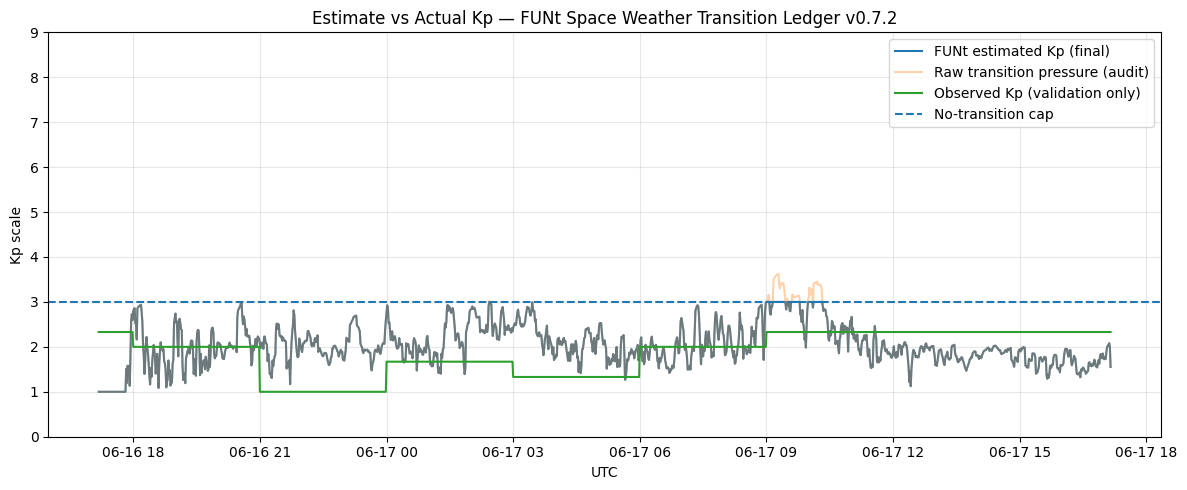

In [10]:
# --------------------- CHART 1: ESTIMATE VS ACTUAL + RAW PRESSURE ---------------------

plt.figure(figsize=(12, 5))
plt.plot(ledger.index, ledger["funt_estimated_kp"], label="FUNt estimated Kp (final)")
plt.plot(ledger.index, ledger["raw_transition_pressure_kp"], alpha=0.35, label="Raw transition pressure (audit)")
if "observed_kp_validation_only" in ledger.columns:
    plt.plot(ledger.index, ledger["observed_kp_validation_only"], label="Observed Kp (validation only)")
plt.axhline(CONFIG["kp_cap_no_transition"], linestyle="--", label="No-transition cap")
plt.ylim(0, 9)
plt.title("Estimate vs Actual Kp — FUNt Space Weather Transition Ledger v0.7.2")
plt.ylabel("Kp scale")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Transition ledger: the meaning decoder

This chart explains why the estimate behaves as it does.

If raw pressure rises but the final Kp remains capped, the model is saying:

> Disturbance detected. Transition not confirmed.




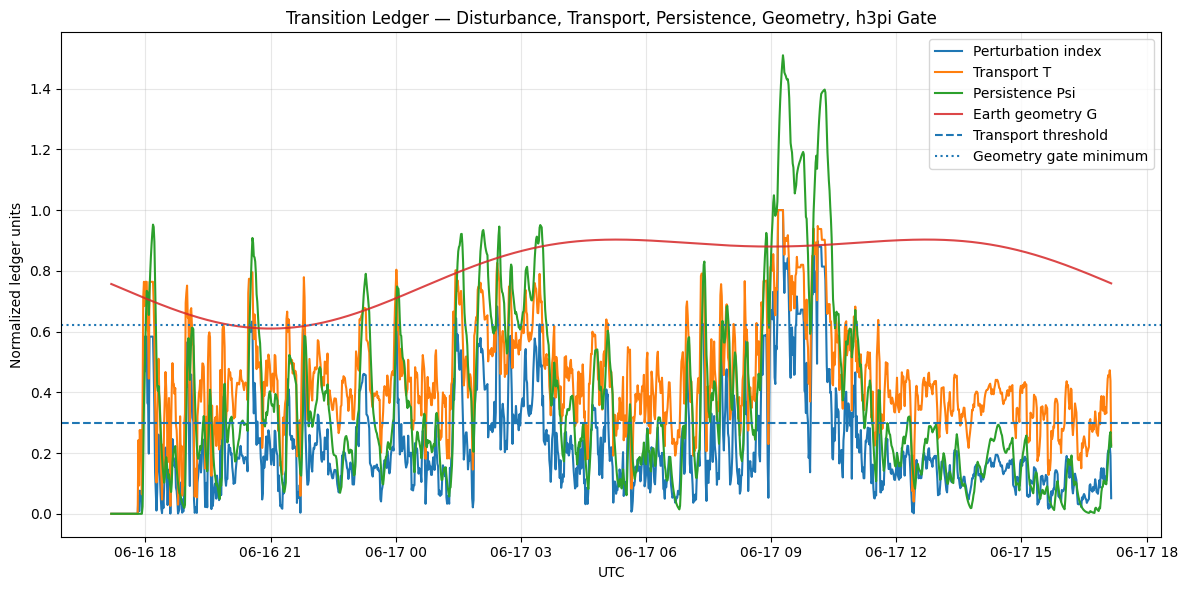

In [11]:
# --------------------- CHART 2: TRANSITION LEDGER ---------------------

plt.figure(figsize=(12, 6))
plt.plot(ledger.index, ledger["perturbation_index"], label="Perturbation index")
plt.plot(ledger.index, ledger["transport_T"], label="Transport T")
plt.plot(ledger.index, ledger["Psi_persistence"], label="Persistence Psi")
plt.plot(ledger.index, ledger["G_geometry"], label="Earth geometry G", alpha=0.85)
plt.axhline(CONFIG["transport_threshold"], linestyle="--", label="Transport threshold")
plt.axhline(CONFIG["geometry_gate_min"], linestyle=":", label="Geometry gate minimum")

# Mark candidate and confirmed h3pi openings separately.
if ledger["h3pi_candidate"].any():
    cand_times = ledger.index[ledger["h3pi_candidate"]]
    plt.scatter(cand_times, ledger.loc[cand_times, "transport_T"], marker="o", s=35, label="h3pi candidate")
if ledger["h3pi_gate"].any():
    gate_times = ledger.index[ledger["h3pi_gate"]]
    plt.scatter(gate_times, ledger.loc[gate_times, "transport_T"], marker="x", s=70, label="h3pi confirmed")

plt.title("Transition Ledger — Disturbance, Transport, Persistence, Geometry, h3pi Gate")
plt.ylabel("Normalized ledger units")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Energy pressure vs h3pi threshold

This audit plot separates **raw internal pressure** from **geometry-coupled pressure**. A raw pressure spike may be real as an impulse, but final transition requires coupled pressure plus survival x.


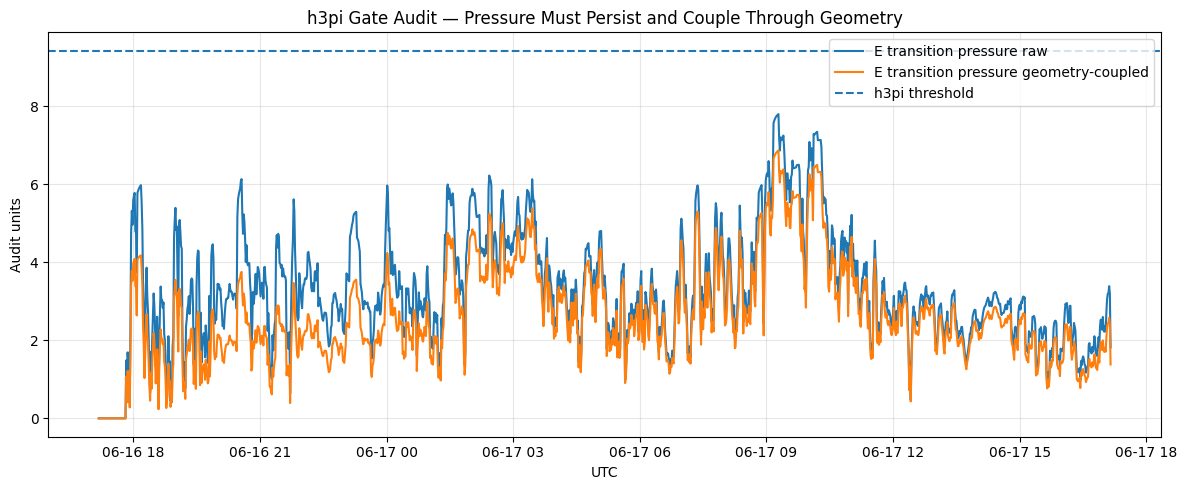

In [12]:
# --------------------- CHART 3: H3PI ENERGY GATE ---------------------

plt.figure(figsize=(12, 5))
plt.plot(ledger.index, ledger["E_transition_pressure_raw"], label="E transition pressure raw")
plt.plot(ledger.index, ledger["E_transition_pressure"], label="E transition pressure geometry-coupled")
plt.axhline(CONFIG["h3pi"], linestyle="--", label="h3pi threshold")
plt.title("h3pi Gate Audit — Pressure Must Persist and Couple Through Geometry")
plt.ylabel("Audit units")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Earth geometry gate

This chart is not a claim that the current geometry proxy is final. It is an explicit placeholder boundary condition:

> The model should ask whether Earth geometry at that time admits coupling, not only whether pressure exists.

Future versions can replace this proxy with real subsolar point, dipole tilt, GSM coordinates, GOES local time, and solar-wind lag correction.


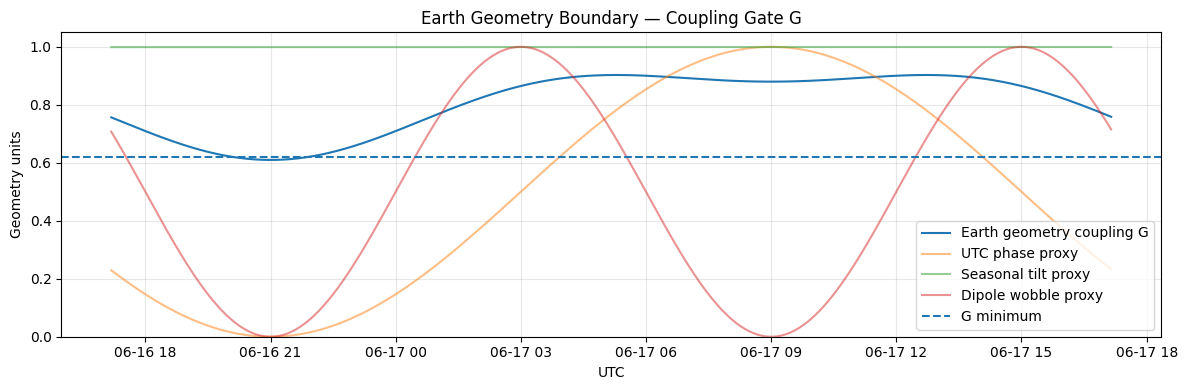

In [13]:
# --------------------- CHART 4: EARTH GEOMETRY GATE ---------------------

plt.figure(figsize=(12, 4))
plt.plot(ledger.index, ledger["G_geometry"], label="Earth geometry coupling G")
plt.plot(ledger.index, ledger["geometry_utc_phase"], alpha=0.5, label="UTC phase proxy")
plt.plot(ledger.index, ledger["geometry_season_phase"], alpha=0.5, label="Seasonal tilt proxy")
plt.plot(ledger.index, ledger["geometry_dipole_phase"], alpha=0.5, label="Dipole wobble proxy")
plt.axhline(CONFIG["geometry_gate_min"], linestyle="--", label="G minimum")
plt.ylim(0, 1.05)
plt.title("Earth Geometry Boundary — Coupling Gate G")
plt.ylabel("Geometry units")
plt.xlabel("UTC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Raw pressure audit events

These rows identify places where the model wanted to exceed the no-transition cap or produced a needle-like raw pressure impulse.

They are not automatically classified as storms. They are stress-test events for improving the boundary conditions.




In [14]:
# --------------------- RAW PRESSURE / SUPPRESSION AUDIT EVENTS ---------------------

audit_cols = [
    "perturbation_index",
    "transport_T",
    "Psi_persistence",
    "tau_persistent_windows",
    "candidate_survival_count",
    "G_geometry",
    "E_transition_pressure_raw",
    "E_transition_pressure",
    "raw_transition_pressure_kp",
    "funt_estimated_kp",
    "h3pi_candidate",
    "condition_survives_x",
    "condition_geometry_ge_min",
    "h3pi_gate",
    "no_transition_cap_active",
    "persistence_suppression_audit",
    "geometry_suppression_audit",
    "needle_spike_audit",
    "funt_state",
]
if "observed_kp_validation_only" in ledger.columns:
    audit_cols.append("observed_kp_validation_only")

pressure_events = ledger.loc[
    ledger["no_transition_cap_active"]
    | ledger["needle_spike_audit"]
    | ledger["persistence_suppression_audit"]
    | ledger["geometry_suppression_audit"],
    audit_cols
].copy()

if pressure_events.empty:
    print("No raw-pressure, persistence-suppression, geometry-suppression, or needle audit events in this run.")
else:
    print(f"Audit events: {len(pressure_events)}")
    display(pressure_events.tail(25))


Audit events: 59


,perturbation_index,transport_T,Psi_persistence,tau_persistent_windows,candidate_survival_count,G_geometry,E_transition_pressure_raw,E_transition_pressure,raw_transition_pressure_kp,funt_estimated_kp,h3pi_candidate,condition_survives_x,condition_geometry_ge_min,h3pi_gate,no_transition_cap_active,persistence_suppression_audit,geometry_suppression_audit,needle_spike_audit,funt_state,observed_kp_validation_only
time_tag,,,,,,,,,,,,,,,,,,,,
2026-06-17 09:43:00+00:00,0.672242,0.819903,1.173670,47,0,0.881674,6.489718,5.721818,3.132582,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,2.33
2026-06-17 09:44:00+00:00,0.672242,0.819903,1.180769,48,0,0.881757,6.494632,5.726689,3.135066,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,2.33
2026-06-17 09:45:00+00:00,0.672242,0.819903,1.186590,49,0,0.881842,6.498641,5.730775,3.137104,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,2.33
2026-06-17 09:46:00+00:00,0.672242,0.819903,1.191363,50,0,0.881928,6.501916,5.734224,3.138774,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,2.33
2026-06-17 09:47:00+00:00,0.627365,0.792064,1.183585,51,0,0.882016,6.326025,5.579658,3.077589,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,2.33
2026-06-17 09:59:00+00:00,0.721220,0.849247,0.793007,63,0,0.883200,6.360753,5.617814,3.060970,3.0,False,False,True,False,True,False,False,True,capped pressure / no transition,2.33
2026-06-17 10:00:00+00:00,0.722743,0.850143,0.881326,64,0,0.883308,6.446796,5.694508,3.093765,3.0,False,False,True,False,True,False,False,False,capped pressure / no transition,2.33
2026-06-17 10:01:00+00:00,0.882393,0.939358,0.991218,65,0,0.883418,7.085475,6.259439,3.319578,3.0,False,False,True,False,True,False,False,True,capped pressure / no transition,2.33
2026-06-17 10:02:00+00:00,0.729947,0.854369,1.045634,66,0,0.883530,6.607466,5.837894,3.160147,3.0,False,False,True,False,True,False,False,True,capped pressure / no transition,2.33


## Frozen run log

Each run can append the latest verdict to a CSV file. This makes performance monitoring cumulative.

Important: this log should not be edited retroactively. If model constants change, change the version label.



In [15]:
# --------------------- APPEND RUN LOG ---------------------

log_path = Path(CONFIG["prediction_log_csv"])
new_row = pd.DataFrame([verdict | metrics])

if log_path.exists():
    old = pd.read_csv(log_path)
    combined = pd.concat([old, new_row], ignore_index=True)
else:
    combined = new_row

combined.to_csv(log_path, index=False)
print(f"Saved/updated run log: {log_path.resolve()}")
display(combined.tail(10))


Saved/updated run log: /content/funt_space_weather_predictions_v072.csv


,run_utc,version,synthetic_demo_mode,latest_time_utc,perturbation_detected,transport_response,persistence_threshold_met,survived_x_windows,geometry_gate_open,G_geometry,h3pi_candidate,h3pi_transition_confirmed,storm_regime,aftershock_watch,state,raw_transition_pressure_kp,funt_estimated_kp_final,no_transition_cap_active,observed_kp_validation_only,estimate_minus_actual,n_validation_points,mae,rmse,bias_est_minus_actual,correlation,max_abs_error
0,2026-06-17T17:11:08.320135+00:00,v0.7.2-geometry-gate-persistence-survival,False,2026-06-17T17:09:00+00:00,False,False,False,False,True,0.759,False,False,False,False,quiet / reference,1.553,1.553,False,2.33,-0.777,1439,0.596754,0.704086,0.166119,-0.101986,1.811931


## Nature's lesson

**Nature teaches that potential difference instills correction, but correction must survive time and geometry.**

Most disturbances are corrected through transport and relaxation. A new regime appears only when correction cannot dissipate persistent strain before the h3pi threshold is crossed **and** Earth geometry admits coupling.

In this notebook's language:

```text
Reference -> Potential Difference -> Transport -> Persistence -> Survival x -> Geometry Gate -> h3pi Gate -> Transition or Relaxation -> Reference
```

If the model disagrees with Nature, the model is revised, not Nature.


## Notes for future versions

Recommended next improvements:

1. Replace the first-pass geometry proxy with real subsolar point, dipole tilt, GSM coordinates, and GOES local time.
2. Add explicit OMNI / DSCOVR solar wind lag correction.
3. Separate current-state estimation from 1-window aftershock watch.
4. Store every run with a hash of the configuration dictionary.
5. Add confusion matrix for storm/no-storm classification once enough runs exist.
6. Add event notebooks: quiet interval, false alarm, storm transition, suppressed transition, aftershock relaxation.

The goal is not to force every event into a storm prediction. The goal is to learn when Nature corrects the disturbance before transition and when Nature crosses into a new regime.
